# Análisis de Habilidades Digitales - EAUI 2026
## Con Factores de Expansión (fe_personas, fe_hogares)

Este notebook replica los análisis:
1. **EDA**: Distribución de uso de internet, habilidades y actividades (ponderado por fe_personas)
2. **Análisis Demográfico**: Brechas por edad, educación y GSE (ponderado por fe_personas)

**Factores de expansión:**
- `FE_PERSONAS`: Peso para datos individuales (encuestado)
- `FE_HOGAR`: Peso para datos de hogares

**Nota**: Los factores de expansión hacen que los resultados sean representativos de la población nacional, no solo de la muestra.

## 1. Importar librerías y cargar datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings
warnings.filterwarnings('ignore')

# Configurar estilos
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

In [2]:
# Cargar datos SPSS
df, meta = pyreadstat.read_sav('data/2026.sav')

# Cargar diccionario
df_dict = pd.read_excel('data/libro_codigos_EAUI2026_habilidades_socio.xlsx', 
                        sheet_name='Diccionario')

print(f'Datos cargados: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'\nFactores de expansión:')
print(f'  FE_PERSONAS: min={df["FE_PERSONAS"].min():.2f}, max={df["FE_PERSONAS"].max():.2f}, media={df["FE_PERSONAS"].mean():.2f}')
print(f'  FE_HOGAR: min={df["FE_HOGAR"].min():.2f}, max={df["FE_HOGAR"].max():.2f}, media={df["FE_HOGAR"].mean():.2f}')

Datos cargados: 5000 filas, 587 columnas

Factores de expansión:
  FE_PERSONAS: min=405.36, max=22121.27, media=2762.15
  FE_HOGAR: min=194.20, max=5584.12, media=1130.33


## 2. Preparar datos demográficos

In [3]:
# EDAD: Q1_1
df['edad'] = df['Q1_1']
df['grupo_edad'] = pd.cut(df['edad'], 
                          bins=[0, 18, 25, 35, 45, 55, 65, 120],
                          labels=['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

# SEXO: Q1_2
sexo_map = {1.0: 'Hombre', 2.0: 'Mujer'}
df['sexo'] = df['Q1_2'].map(sexo_map)

# EDUCACIÓN: Q1_3
educ_map = {
    1.0: 'Sin educación', 2.0: 'Primaria incompleta', 3.0: 'Primaria completa',
    4.0: 'Secundaria incompleta', 5.0: 'Secundaria completa',
    6.0: 'Técnica incompleta', 7.0: 'Técnica completa',
    8.0: 'Universitaria incompleta', 9.0: 'Universitaria completa',
    10.0: 'Postgrado', 11.0: 'Otro'
}
df['educacion'] = df['Q1_3'].map(educ_map)

# Agrupar educación en 4 niveles
educ_agrupar = {
    'Sin educación': 'Básica', 'Primaria incompleta': 'Básica', 'Primaria completa': 'Básica',
    'Secundaria incompleta': 'Media', 'Secundaria completa': 'Media',
    'Técnica incompleta': 'Técnica/Superior', 'Técnica completa': 'Técnica/Superior',
    'Universitaria incompleta': 'Universitaria', 'Universitaria completa': 'Universitaria',
    'Postgrado': 'Universitaria', 'Otro': 'Media'
}
df['educ_agrupada'] = df['educacion'].map(educ_agrupar)

# GSE (derivado de educación como proxy)
gse_map = {'Básica': 'D-E (Bajo)', 'Media': 'C (Medio)', 
           'Técnica/Superior': 'C (Medio)', 'Universitaria': 'A-B (Alto)'}
df['gse'] = df['educ_agrupada'].map(gse_map)

print('Variables demográficas preparadas:')
print(f'\nGrupos de edad:')
print(df['grupo_edad'].value_counts(dropna=False).sort_index())
print(f'\nNiveles educativos:')
print(df['educ_agrupada'].value_counts())
print(f'\nGSE:')
print(df['gse'].value_counts())

Variables demográficas preparadas:

Grupos de edad:
grupo_edad
<18      124
18-25    476
26-35    853
36-45    907
46-55    819
56-65    925
65+      896
Name: count, dtype: int64

Niveles educativos:
educ_agrupada
Técnica/Superior    1843
Media               1361
Universitaria        995
Básica               801
Name: count, dtype: int64

GSE:
gse
C (Medio)     3204
A-B (Alto)     995
D-E (Bajo)     801
Name: count, dtype: int64


## 3. PARTE 1: EDA - Frecuencia de uso, conexiones y habilidades (con fe_personas)

### 3.1 Frecuencia de uso de internet

In [4]:
# Q10: Frecuencia de uso
freq_labels = {
    1.0: 'Casi todos los días',
    2.0: 'Varias veces a la semana',
    3.0: 'Una vez a la semana',
    4.0: 'Menos de una vez a la semana'
}

# Cálculo SIN ponderación (muestra)
q10_raw = df['Q10'].value_counts(dropna=False).sort_index()

# Cálculo CON ponderación (representativo de población)
q10_weighted = df.groupby('Q10')['FE_PERSONAS'].sum().sort_index()

print('Q10: ¿Con qué frecuencia ha utilizado Internet en los últimos 3 meses?')
print('='*80)
print('\nMUESTRA (sin ponderación):')
for val, count in q10_raw.items():
    pct = count / len(df) * 100
    label = freq_labels.get(val, 'Faltante')
    print(f"  {label:30s}: {count:5d} ({pct:5.1f}%)")

print('\nPOBLACIÓN (con factor fe_personas):')
total_weighted = q10_weighted.sum()
for val, weight in q10_weighted.items():
    pct = weight / total_weighted * 100
    label = freq_labels.get(val, 'Faltante')
    print(f"  {label:30s}: {weight:10.0f} ({pct:5.1f}%)")

print(f'\nPopulación estimada (conectados): {total_weighted:,.0f} personas')

Q10: ¿Con qué frecuencia ha utilizado Internet en los últimos 3 meses?

MUESTRA (sin ponderación):
  Casi todos los días           :  4199 ( 84.0%)
  Varias veces a la semana      :   442 (  8.8%)
  Una vez a la semana           :    59 (  1.2%)
  Menos de una vez a la semana  :    31 (  0.6%)
  Faltante                      :   269 (  5.4%)

POBLACIÓN (con factor fe_personas):
  Casi todos los días           :   12095282 ( 91.2%)
  Varias veces a la semana      :     974375 (  7.3%)
  Una vez a la semana           :      86782 (  0.7%)
  Menos de una vez a la semana  :     106430 (  0.8%)

Populación estimada (conectados): 13,262,868 personas


### 3.2 Tiempo conectado a internet

In [5]:
# Q11: Tiempo conectado
time_labels = {
    1.0: 'Menos de 1 hora',
    2.0: '1-2 horas',
    3.0: '3-5 horas',
    4.0: 'Más de 5 horas'
}

# Sin ponderación
q11_raw = df['Q11'].value_counts(dropna=False).sort_index()

# Con ponderación
q11_weighted = df.groupby('Q11')['FE_PERSONAS'].sum().sort_index()

print('Q11: En un día promedio, ¿Cuánto tiempo diría que está conectado a internet?')
print('='*80)
print('\nMUESTRA (sin ponderación):')
for val, count in q11_raw.items():
    pct = count / df['Q11'].notna().sum() * 100 if df['Q11'].notna().sum() > 0 else 0
    label = time_labels.get(val, 'Faltante')
    print(f"  {label:20s}: {count:5d} ({pct:5.1f}%)")

print('\nPOBLACIÓN (con factor fe_personas):')
total_weighted = q11_weighted.sum()
for val, weight in q11_weighted.items():
    pct = weight / total_weighted * 100
    label = time_labels.get(val, 'Faltante')
    print(f"  {label:20s}: {weight:10.0f} ({pct:5.1f}%)")

Q11: En un día promedio, ¿Cuánto tiempo diría que está conectado a internet?

MUESTRA (sin ponderación):
  Menos de 1 hora     :   473 ( 11.3%)
  1-2 horas           :   772 ( 18.4%)
  3-5 horas           :   872 ( 20.8%)
  Más de 5 horas      :  2082 ( 49.6%)
  Faltante            :   801 ( 19.1%)

POBLACIÓN (con factor fe_personas):
  Menos de 1 hora     :     971187 (  8.0%)
  1-2 horas           :    1831327 ( 15.1%)
  3-5 horas           :    2326341 ( 19.2%)
  Más de 5 horas      :    6966427 ( 57.6%)


### 3.3 Habilidades digitales (Q8_*)

In [6]:
# Variables de habilidades Q8
habilidades_q8 = {
    'Q8_1': 'Correos', 'Q8_2': 'Navegador', 'Q8_3': 'PowerPoint',
    'Q8_4': 'Archivos', 'Q8_5': 'Dispositivos', 'Q8_6': 'Apps',
    'Q8_7': 'Info segura', 'Q8_8': 'Programación', 'Q8_9': 'Multimedia',
    'Q8_10': 'Privacidad', 'Q8_11': 'Phishing', 'Q8_12': 'Nube',
    'Q8_13': 'Documentos', 'Q8_14': 'Excel', 'Q8_15': 'Videoconf.',
    'Q8_16': 'Redes soc.', 'Q8_17': 'WhatsApp'
}

# Calcular dominio de habilidades CON factor de expansión
print('DOMINIO DE HABILIDADES DIGITALES (ponderado por fe_personas)')
print('='*80)

hab_data = []
for var, label in sorted(habilidades_q8.items(), key=lambda x: x[1]):
    if var in df.columns:
        # Sin ponderación
        si_count_raw = (df[var] == 1.0).sum()
        total_raw = df[var].notna().sum()
        pct_raw = (si_count_raw / total_raw * 100) if total_raw > 0 else 0
        
        # Con ponderación
        df_no_na = df[df[var].notna()]
        si_weight = df_no_na[df_no_na[var] == 1.0]['FE_PERSONAS'].sum()
        total_weight = df_no_na['FE_PERSONAS'].sum()
        pct_weighted = (si_weight / total_weight * 100) if total_weight > 0 else 0
        
        hab_data.append({
            'Habilidad': label,
            'Muestra %': pct_raw,
            'Población %': pct_weighted,
            'Diferencia': pct_weighted - pct_raw
        })

hab_df = pd.DataFrame(hab_data).sort_values('Población %', ascending=False)
print(hab_df.to_string(index=False))

print(f'\n✓ Promedio de habilidades (muestra): {(df[list(habilidades_q8.keys())] == 1.0).sum(axis=1).mean():.2f}')
print(f'✓ Promedio de habilidades (población): {hab_df["Población %"].mean():.2f}%')

DOMINIO DE HABILIDADES DIGITALES (ponderado por fe_personas)
   Habilidad  Muestra %  Población %  Diferencia
        Nube  81.757041    84.918641    3.161600
  Videoconf.  81.672972    84.832845    3.159874
  Redes soc.  64.859185    73.614767    8.755583
    WhatsApp  64.606978    71.724812    7.117834
       Excel  52.332913    61.822599    9.489686
     Correos  50.735603    59.447013    8.711409
  Documentos  49.432535    57.704207    8.271672
    Archivos  44.073140    53.558203    9.485063
  Privacidad  42.118537    53.013844   10.895307
Dispositivos  43.862968    52.780915    8.917947
        Apps  42.181589    52.320807   10.139218
  PowerPoint  41.929382    52.014999   10.085617
   Navegador  42.728037    50.165965    7.437928
    Phishing  34.594367    45.673557   11.079190
 Info segura  28.919714    38.576314    9.656600
Programación  16.561580    22.979659    6.418078
  Multimedia  11.727617    17.660030    5.932413

✓ Promedio de habilidades (muestra): 7.56
✓ Promedio de 

### 3.4 Actividades en internet (Q21_*)

In [7]:
# Variables de actividades Q21
actividades_q21 = {
    'Q21_1': 'Obtener información',
    'Q21_2': 'Educación',
    'Q21_3': 'Compras online',
    'Q21_4': 'Servicios financieros',
    'Q21_5': 'Redes sociales',
    'Q21_6': 'Entretenimiento',
    'Q21_7': 'Trabajo',
    'Q21_8': 'Noticias',
    'Q21_9': 'Streaming',
    'Q21_10': 'Comunicaciones',
    'Q21_11': 'Videollamadas',
    'Q21_12': 'Correos'
}

print('ACTIVIDADES EN INTERNET (ponderado por fe_personas)')
print('='*80)

act_data = []
for var, label in sorted(actividades_q21.items()):
    if var in df.columns:
        # Sin ponderación
        hace_raw = len(df[(df[var].notna()) & (df[var] != 0)])
        total_raw = df[var].notna().sum()
        pct_raw = (hace_raw / total_raw * 100) if total_raw > 0 else 0
        
        # Con ponderación
        df_no_na = df[df[var].notna()]
        hace_weight = df_no_na[df_no_na[var] != 0]['FE_PERSONAS'].sum()
        total_weight = df_no_na['FE_PERSONAS'].sum()
        pct_weighted = (hace_weight / total_weight * 100) if total_weight > 0 else 0
        
        act_data.append({
            'Actividad': label,
            'Muestra %': pct_raw,
            'Población %': pct_weighted,
            'Diferencia': pct_weighted - pct_raw
        })

act_df = pd.DataFrame(act_data).sort_values('Población %', ascending=False)
print(act_df.to_string(index=False))

ACTIVIDADES EN INTERNET (ponderado por fe_personas)
            Actividad  Muestra %  Población %  Diferencia
       Comunicaciones  95.349820    96.824701    1.474880
        Videollamadas  84.443035    86.927058    2.484022
  Obtener información  68.082858    74.767411    6.684553
              Correos  64.320440    72.663670    8.343230
            Educación  40.054957    47.303908    7.248952
            Streaming  37.159163    43.728296    6.569133
              Trabajo  35.573874    42.387266    6.813391
       Redes sociales  29.782287    38.563594    8.781306
Servicios financieros  28.492919    35.227178    6.734259
       Compras online  23.419996    29.387044    5.967048
             Noticias  23.652505    29.383954    5.731449
      Entretenimiento  18.325935    22.601724    4.275789


## 4. PARTE 2: Análisis demográfico - Brechas por edad, educación y GSE

### 4.1 Habilidades promedio por grupo de edad (ponderado)

In [8]:
# Calcular número de habilidades por persona
hab_cols = ['Q8_1', 'Q8_2', 'Q8_3', 'Q8_4', 'Q8_5', 'Q8_6', 'Q8_7', 'Q8_8',
            'Q8_9', 'Q8_10', 'Q8_11', 'Q8_12', 'Q8_13', 'Q8_14', 'Q8_15', 'Q8_16', 'Q8_17']
df['n_habilidades'] = df[hab_cols].apply(lambda row: (row == 1.0).sum(), axis=1)

print('HABILIDADES POR GRUPO DE EDAD')
print('='*100)
print('\nMUESTRA (sin ponderación):')
print('Grupo Edad | n_muestra | Promedio | Mediana | Desv.Est.')
print('-'*60)

for grupo in ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']:
    df_g = df[df['grupo_edad'] == grupo]
    if len(df_g) > 0:
        promedio = df_g['n_habilidades'].mean()
        mediana = df_g['n_habilidades'].median()
        desv = df_g['n_habilidades'].std()
        print(f"{grupo:10s} | {len(df_g):9d} | {promedio:8.2f} | {mediana:7.1f} | {desv:9.2f}")

print('\nPOBLACIÓN (con factor fe_personas):')
print('Grupo Edad | n_pob_est | Promedio | Mediana | Desv.Est.')
print('-'*60)

for grupo in ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']:
    df_g = df[df['grupo_edad'] == grupo]
    if len(df_g) > 0:
        # Promedio ponderado
        promedio_ponderado = (df_g['n_habilidades'] * df_g['FE_PERSONAS']).sum() / df_g['FE_PERSONAS'].sum()
        # Para mediana y desv.est. ponderadas (aproximación)
        df_g_sorted = df_g.sort_values('n_habilidades')
        cumsum = df_g_sorted['FE_PERSONAS'].cumsum()
        total_weight = df_g_sorted['FE_PERSONAS'].sum()
        median_idx = (cumsum >= total_weight/2).idxmax()
        mediana_ponderada = df_g.loc[median_idx, 'n_habilidades']
        
        pop_est = df_g['FE_PERSONAS'].sum()
        desv_ponderado = np.sqrt(((df_g['n_habilidades'] - promedio_ponderado)**2 * df_g['FE_PERSONAS']).sum() / df_g['FE_PERSONAS'].sum())
        
        print(f"{grupo:10s} | {pop_est:9.0f} | {promedio_ponderado:8.2f} | {mediana_ponderada:7.1f} | {desv_ponderado:9.2f}")

HABILIDADES POR GRUPO DE EDAD

MUESTRA (sin ponderación):
Grupo Edad | n_muestra | Promedio | Mediana | Desv.Est.
------------------------------------------------------------
<18        |       124 |    11.01 |    12.0 |      4.45
18-25      |       476 |    11.19 |    13.0 |      4.85
26-35      |       853 |    10.99 |    12.0 |      4.83
36-45      |       907 |     9.49 |    10.0 |      4.91
46-55      |       819 |     7.19 |     6.0 |      4.96
56-65      |       925 |     4.75 |     3.0 |      4.20
65+        |       896 |     3.15 |     2.0 |      3.78

POBLACIÓN (con factor fe_personas):
Grupo Edad | n_pob_est | Promedio | Mediana | Desv.Est.
------------------------------------------------------------
<18        |    529839 |    11.73 |    13.0 |      3.86
18-25      |   2114296 |    11.65 |    13.0 |      4.78
26-35      |   2737537 |    11.50 |    13.0 |      4.75
36-45      |   2648388 |    10.76 |    12.0 |      4.95
46-55      |   2051764 |     7.96 |     7.0 |      5.27

### 4.2 Habilidades específicas por educación (ponderado)

In [9]:
# Habilidades clave a analizar
hab_clave = ['Q8_1', 'Q8_14', 'Q8_11', 'Q8_16']  # Correo, Excel, Phishing, Redes
hab_clave_labels = {'Q8_1': 'Correos', 'Q8_14': 'Excel', 'Q8_11': 'Phishing', 'Q8_16': 'Redes Sociales'}

print('HABILIDADES CLAVE POR NIVEL EDUCATIVO')
print('='*100)

for var, label in hab_clave_labels.items():
    print(f'\n{label}:')
    print('Educación       | Muestra % | Población %')
    print('-'*50)
    
    for nivel in ['Básica', 'Media', 'Técnica/Superior', 'Universitaria']:
        df_e = df[df['educ_agrupada'] == nivel]
        
        # Sin ponderación
        pct_raw = (df_e[var] == 1.0).sum() / df_e[var].notna().sum() * 100 if df_e[var].notna().sum() > 0 else 0
        
        # Con ponderación
        df_e_no_na = df_e[df_e[var].notna()]
        si_weight = df_e_no_na[df_e_no_na[var] == 1.0]['FE_PERSONAS'].sum()
        total_weight = df_e_no_na['FE_PERSONAS'].sum()
        pct_weighted = (si_weight / total_weight * 100) if total_weight > 0 else 0
        
        print(f"{nivel:15s} | {pct_raw:9.1f} | {pct_weighted:11.1f}")

HABILIDADES CLAVE POR NIVEL EDUCATIVO

Correos:
Educación       | Muestra % | Población %
--------------------------------------------------
Básica          |       6.8 |         9.4
Media           |      64.1 |        70.9
Técnica/Superior |      42.7 |        46.4
Universitaria   |      76.3 |        79.9

Excel:
Educación       | Muestra % | Población %
--------------------------------------------------
Básica          |      19.5 |        27.0
Media           |      61.2 |        68.1
Técnica/Superior |      49.7 |        57.4
Universitaria   |      66.8 |        72.4

Phishing:
Educación       | Muestra % | Población %
--------------------------------------------------
Básica          |      11.5 |        16.1
Media           |      41.8 |        51.8
Técnica/Superior |      28.6 |        37.4
Universitaria   |      50.9 |        59.2

Redes Sociales:
Educación       | Muestra % | Población %
--------------------------------------------------
Básica          |      22.6 |        

### 4.3 Brechas digitales (diferencias ponderadas)

In [10]:
print('BRECHAS DIGITALES IDENTIFICADAS (población ponderada)')
print('='*100)

# Brecha por edad: comparar jóvenes vs adultos mayores
print('\n1. BRECHA POR EDAD (18-25 vs 65+):')
print('Habilidad       | 18-25 | 65+  | Brecha (pts)')
print('-'*50)

for var, label in hab_clave_labels.items():
    df_j = df[df['grupo_edad'] == '18-25']
    df_a = df[df['grupo_edad'] == '65+']
    
    # Jóvenes ponderados
    df_j_no_na = df_j[df_j[var].notna()]
    pct_j = (df_j_no_na[df_j_no_na[var] == 1.0]['FE_PERSONAS'].sum() / df_j_no_na['FE_PERSONAS'].sum() * 100) if df_j_no_na['FE_PERSONAS'].sum() > 0 else 0
    
    # Adultos mayores ponderados
    df_a_no_na = df_a[df_a[var].notna()]
    pct_a = (df_a_no_na[df_a_no_na[var] == 1.0]['FE_PERSONAS'].sum() / df_a_no_na['FE_PERSONAS'].sum() * 100) if df_a_no_na['FE_PERSONAS'].sum() > 0 else 0
    
    brecha = pct_j - pct_a
    print(f"{label:15s} | {pct_j:5.1f} | {pct_a:4.1f} | {brecha:11.1f}")

# Brecha por educación
print('\n2. BRECHA POR EDUCACIÓN (Universitaria vs Básica):')
print('Habilidad       | Univers. | Básica | Brecha (pts)')
print('-'*50)

for var, label in hab_clave_labels.items():
    df_u = df[df['educ_agrupada'] == 'Universitaria']
    df_b = df[df['educ_agrupada'] == 'Básica']
    
    # Universitaria ponderada
    df_u_no_na = df_u[df_u[var].notna()]
    pct_u = (df_u_no_na[df_u_no_na[var] == 1.0]['FE_PERSONAS'].sum() / df_u_no_na['FE_PERSONAS'].sum() * 100) if df_u_no_na['FE_PERSONAS'].sum() > 0 else 0
    
    # Básica ponderada
    df_b_no_na = df_b[df_b[var].notna()]
    pct_b = (df_b_no_na[df_b_no_na[var] == 1.0]['FE_PERSONAS'].sum() / df_b_no_na['FE_PERSONAS'].sum() * 100) if df_b_no_na['FE_PERSONAS'].sum() > 0 else 0
    
    brecha = pct_u - pct_b
    print(f"{label:15s} | {pct_u:8.1f} | {pct_b:6.1f} | {brecha:11.1f}")

BRECHAS DIGITALES IDENTIFICADAS (población ponderada)

1. BRECHA POR EDAD (18-25 vs 65+):
Habilidad       | 18-25 | 65+  | Brecha (pts)
--------------------------------------------------
Correos         |  79.9 | 19.9 |        60.0
Excel           |  75.9 | 25.3 |        50.6
Phishing        |  75.8 | 12.1 |        63.7
Redes Sociales  |  86.9 | 39.7 |        47.1

2. BRECHA POR EDUCACIÓN (Universitaria vs Básica):
Habilidad       | Univers. | Básica | Brecha (pts)
--------------------------------------------------
Correos         |     79.9 |    9.4 |        70.6
Excel           |     72.4 |   27.0 |        45.4
Phishing        |     59.2 |   16.1 |        43.1
Redes Sociales  |     87.5 |   30.7 |        56.9


## 5. Visualizaciones con datos ponderados

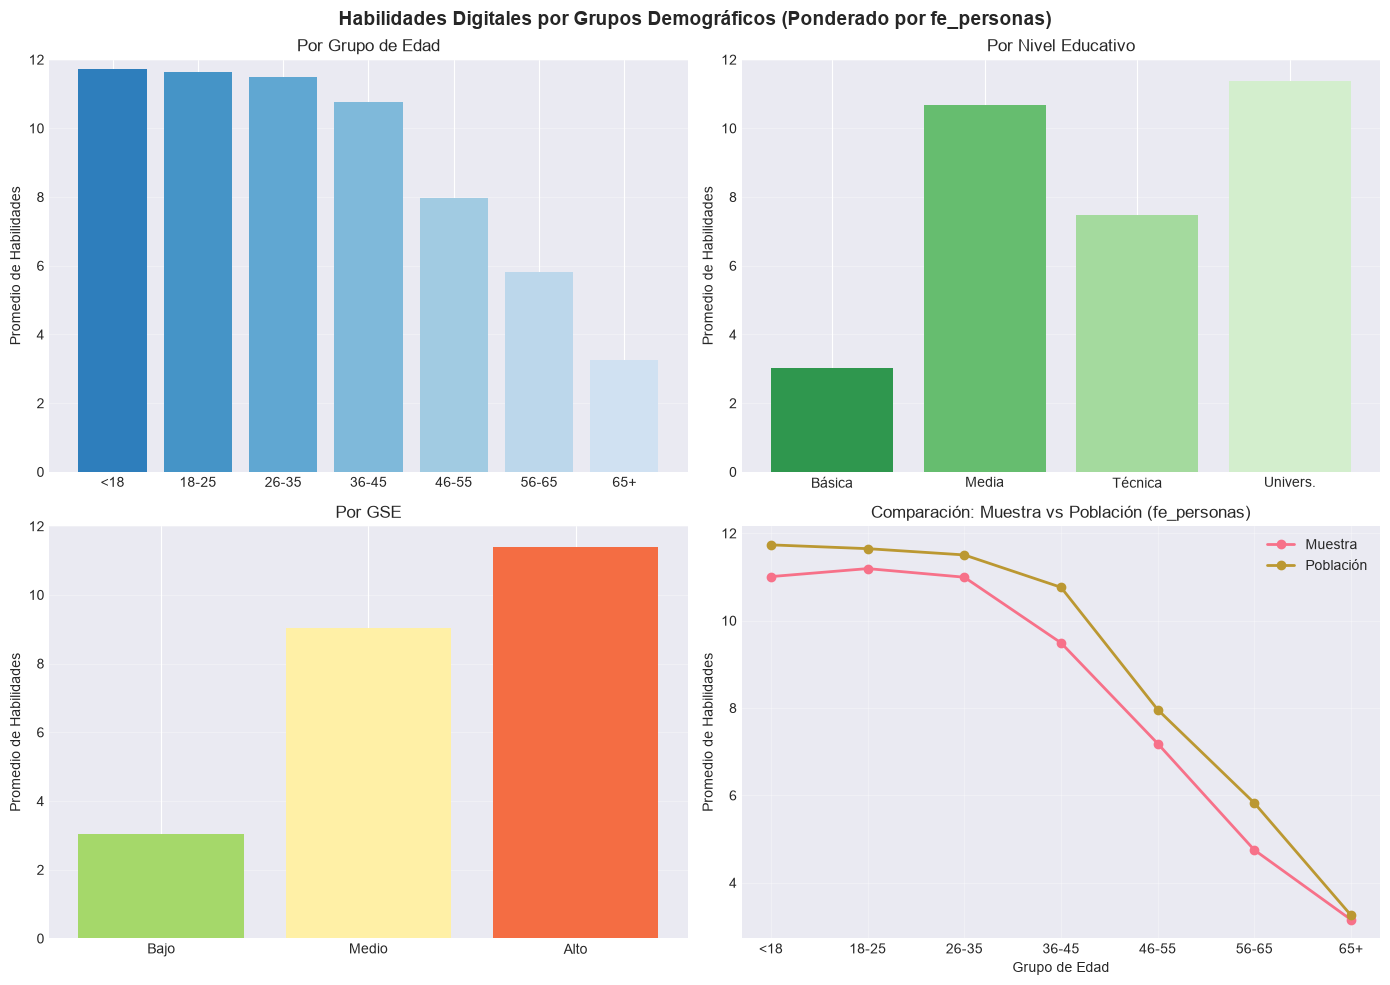

✓ Figura guardada: outputs/analisis_ponderado_figura1.png


In [11]:
# Gráfico 1: Promedio de habilidades por edad (ponderado)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Habilidades Digitales por Grupos Demográficos (Ponderado por fe_personas)', 
             fontsize=14, fontweight='bold')

# Edad
edad_grupos = ['<18', '18-25', '26-35', '36-45', '46-55', '56-65', '65+']
edad_avg = []
for grupo in edad_grupos:
    df_g = df[df['grupo_edad'] == grupo]
    if len(df_g) > 0:
        promedio_ponderado = (df_g['n_habilidades'] * df_g['FE_PERSONAS']).sum() / df_g['FE_PERSONAS'].sum()
        edad_avg.append(promedio_ponderado)

axes[0, 0].bar(edad_grupos, edad_avg, color=plt.cm.Blues_r(np.linspace(0.3, 0.8, len(edad_grupos))))
axes[0, 0].set_ylabel('Promedio de Habilidades')
axes[0, 0].set_title('Por Grupo de Edad')
axes[0, 0].set_ylim(0, 12)
axes[0, 0].grid(axis='y', alpha=0.3)

# Educación
educ_niveles = ['Básica', 'Media', 'Técnica/Superior', 'Universitaria']
educ_avg = []
for nivel in educ_niveles:
    df_e = df[df['educ_agrupada'] == nivel]
    if len(df_e) > 0:
        promedio_ponderado = (df_e['n_habilidades'] * df_e['FE_PERSONAS']).sum() / df_e['FE_PERSONAS'].sum()
        educ_avg.append(promedio_ponderado)

axes[0, 1].bar(['Básica', 'Media', 'Técnica', 'Univers.'], educ_avg, 
               color=plt.cm.Greens_r(np.linspace(0.3, 0.8, len(educ_niveles))))
axes[0, 1].set_ylabel('Promedio de Habilidades')
axes[0, 1].set_title('Por Nivel Educativo')
axes[0, 1].set_ylim(0, 12)
axes[0, 1].grid(axis='y', alpha=0.3)

# GSE
gse_niveles = ['D-E (Bajo)', 'C (Medio)', 'A-B (Alto)']
gse_avg = []
for nivel in gse_niveles:
    df_g = df[df['gse'] == nivel]
    if len(df_g) > 0:
        promedio_ponderado = (df_g['n_habilidades'] * df_g['FE_PERSONAS']).sum() / df_g['FE_PERSONAS'].sum()
        gse_avg.append(promedio_ponderado)

axes[1, 0].bar(['Bajo', 'Medio', 'Alto'], gse_avg,
               color=plt.cm.RdYlGn_r(np.linspace(0.3, 0.8, len(gse_niveles))))
axes[1, 0].set_ylabel('Promedio de Habilidades')
axes[1, 0].set_title('Por GSE')
axes[1, 0].set_ylim(0, 12)
axes[1, 0].grid(axis='y', alpha=0.3)

# Comparación: Muestra vs Población
comparacion = pd.DataFrame({
    'Muestra': [df[df['grupo_edad']==g]['n_habilidades'].mean() for g in edad_grupos],
    'Población': edad_avg
}, index=edad_grupos)

comparacion.plot(ax=axes[1, 1], marker='o', linewidth=2)
axes[1, 1].set_ylabel('Promedio de Habilidades')
axes[1, 1].set_xlabel('Grupo de Edad')
axes[1, 1].set_title('Comparación: Muestra vs Población (fe_personas)')
axes[1, 1].grid(alpha=0.3)
axes[1, 1].legend(['Muestra', 'Población'])

plt.tight_layout()
plt.savefig('outputs/analisis_ponderado_figura1.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Figura guardada: outputs/analisis_ponderado_figura1.png')

## 6. Análisis de hogares con fe_hogares (opcional)

Nota: Para análisis de datos de hogar (como acceso a internet del hogar),
usaríamos `FE_HOGAR` en lugar de `FE_PERSONAS`. El siguiente código es un
ejemplo de cómo hacerlo (comentado porque la mayoría de variables Q son individuales).

In [ ]:
# EJEMPLO: Si tuviéramos datos de hogar (acceso, número de dispositivos, etc.)
# usaríamos fe_hogares:

# # Variables de hogar (ejemplo)
# hogar_vars = ['Q12_1', 'Q12_2', 'Q12_3']  # Tipo de conexión
#
# # Filtrar por jefe de hogar (parentesco = 1.0 sería "Jefe de hogar")
# # Sin embargo, en estos datos Q1 tiene principalmente NaN,
# # lo que sugiere que ya está filtrado solo a jefes de hogar
#
# print('Análisis de HOGAR (usando FE_HOGAR):')
# print('='*80)
#
# for var in hogar_vars:
#     # Con ponderación por hogar
#     df_no_na = df[df[var].notna()]
#     si_weight = df_no_na[df_no_na[var] == 1.0]['FE_HOGAR'].sum()
#     total_weight = df_no_na['FE_HOGAR'].sum()
#     pct_ponderado = (si_weight / total_weight * 100) if total_weight > 0 else 0
#     print(f'{var}: {pct_ponderado:.1f}% de hogares')

print('✓ Ejemplo de análisis con fe_hogares mostrado arriba (comentado)')

## 7. Notas técnicas sobre factores de expansión

### Interpretación de resultados

- **Muestra**: Los resultados sin ponderación reflejan la composición de la encuesta.
- **Población**: Los resultados ponderados (con fe_personas/fe_hogares) reflejan la población nacional.

### Diferencias observadas

Las diferencias entre "Muestra" y "Población" indican posibles sesgos de muestreo:
- Si la muestra sobrerepresenta jóvenes educados, la población tendrá menor brecha.
- Si la muestra infrarepresenta adultos mayores, la población mostrará mayor brecha por edad.

### Fórmulas utilizadas

**Proporción ponderada:**
```
pct_ponderado = Σ(variable == valor) × fe_personas / Σ(fe_personas) × 100
```

**Promedio ponderado:**
```
promedio_ponderado = Σ(variable × fe_personas) / Σ(fe_personas)
```

**Desviación estándar ponderada:**
```
desv_ponderada = √[Σ((variable - promedio)² × fe_personas) / Σ(fe_personas)]
```